# 0. Import Thư viện

In [1]:
import os
import random
import copy
import shutil
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_fscore_support,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from pathlib import Path
from transformers import AutoTokenizer

# Cấu hình đường dẫn dự án
PROJECT_ROOT = Path.cwd().parent
PKL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'tokens_dl_phobert.pkl'
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'shopee_reviews_dataset.jsonl' # Hoặc file dữ liệu chuẩn của bạn
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình thiết bị chạy.
# Mặc định ưu tiên GPU để train nhanh hơn: CUDA -> MPS -> CPU.
# Nếu cần tái lập kết quả chặt hơn để kiểm tra, đổi thành True để ép chạy CPU.
FORCE_CPU_FOR_REPRODUCIBILITY = False

if FORCE_CPU_FOR_REPRODUCIBILITY:
    device = torch.device('cpu')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: mps


# 1. Chuẩn bị dữ liệu

## 1.0 Cố định seed để kết quả dễ tái lập
Việc cố  định seed giúp các lần chia dữ liệu và khởi tạo trọng số ổn định hơn, từ đó việc so sánh các cấu hình LSTM công bằng hơn.

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)

def set_global_seed(seed: int = SEED):
    """Cố định seed cho các thư viện chính để kết quả train dễ tái lập hơn."""
    # random và numpy thường xuất hiện trong các bước chia dữ liệu hoặc xử lý phụ trợ.
    random.seed(seed)
    np.random.seed(seed)

    # torch.manual_seed kiểm soát phần khởi tạo trọng số và một số phép toán trong PyTorch.
    torch.manual_seed(seed)

    # Giới hạn số thread CPU để giảm sai khác do thứ tự tính toán song song.
    # set_num_interop_threads chỉ set được một lần trong mỗi kernel, nên cần bọc try/except khi rerun cell.
    try:
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass

    # Nếu chạy trên CUDA, cần seed toàn bộ GPU để giảm khác biệt giữa các lần chạy.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Cấu hình này ưu tiên tính tái lập hơn tốc độ khi dùng CUDA/cuDNN.
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Khi ép CPU thì bật deterministic algorithms để kết quả ổn định hơn.
    # Khi dùng GPU/MPS thì tắt để ưu tiên tốc độ và tránh cảnh báo operation chưa hỗ trợ deterministic.
    torch.use_deterministic_algorithms(FORCE_CPU_FOR_REPRODUCIBILITY, warn_only=True)

set_global_seed(SEED)
print(f"✅ Đã cố định seed = {SEED}. Reproducibility mode: {'CPU deterministic' if FORCE_CPU_FOR_REPRODUCIBILITY else 'GPU/MPS fast mode'}.")

✅ Đã cố định seed = 42. Reproducibility mode: GPU/MPS fast mode.


## 1.1. Lấy Ground Truth

In [3]:
# 1. Đường dẫn tới file dữ liệu đã được tách từ bằng Underthesea từ thư mục interim
INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim" / "df_lstm_segmented.csv"

# 2. Đọc file CSV lên DataFrame
print(f"Đang đọc dữ liệu sạch từ: {INTERIM_DATA_PATH.name}...")
df = pd.read_csv(INTERIM_DATA_PATH)

# 3. Chuẩn hóa nhãn (Ground Truth) sang dạng số 1/0 : positive/negitive
label_map = {"positive": 1, "negative": 0}
df["label_code"] = df["label"].map(label_map)

# 4. Trích xuất mảng nhãn thành Tensor hệ PyTorch (kiểu float32 để khớp hàm lỗi BCELoss)
y_all = torch.tensor(df["label_code"].values, dtype=torch.float32)

print(f"✅ Đã chuẩn bị xong nhãn Ground Truth (y). Kích thước: {y_all.shape}")
print(f"📊 Phân bố các lớp cảm xúc:\n{df['label'].value_counts()}\n")

# 5. Ghép nhóm label và label_code để kiểm tra có chuẩn hóa sai không
print(df.groupby('label')['label_code'].unique())

Đang đọc dữ liệu sạch từ: df_lstm_segmented.csv...
✅ Đã chuẩn bị xong nhãn Ground Truth (y). Kích thước: torch.Size([10947])
📊 Phân bố các lớp cảm xúc:
label
negative    6642
positive    4305
Name: count, dtype: int64

label
negative    [0]
positive    [1]
Name: label_code, dtype: object


## 1.2: Chuẩn hóa dữ liệu từ tokens_dl_phobert.pkl phù hợp cho LSTM

In [4]:
# 1. Định nghĩa đường dẫn
PKL_PATH = PROJECT_ROOT / "data" / "processed" / "tokens_dl_phobert.pkl"

# 2. Tải dữ liệu từ file pickle lên bộ nhớ bộ đệm
print(f"🔄 Đang tải file tokens từ: {PKL_PATH.name}...")
with open(PKL_PATH, "rb") as f:
    tokens_DL_loaded = pickle.load(f)

# 3. Trích xuất trường 'input_ids' từ danh sách các dictionary
# Mạng LSTM chỉ cần chuỗi số phẳng đại diện cho ID từ, không cần dùng attention_mask
input_ids_numpy = [item['input_ids'].cpu().numpy() if isinstance(item['input_ids'], torch.Tensor) else item['input_ids'] for item in tokens_DL_loaded]

# 4. Chuyển đổi thành PyTorch Tensor kiểu số nguyên LongTensor
X_all = torch.tensor(np.array(input_ids_numpy), dtype=torch.long)

# 5. Kiểm tra tính đồng bộ kích thước giữa đầu vào (X) và nhãn mục tiêu (y_all ở cell trước)
print(f"✅ Đã chuẩn bị xong ma trận đầu vào (X). Kích thước: {X_all.shape}")
print(f"📊 Đối chiếu số lượng mẫu: X_all ({X_all.shape[0]} dòng) vs y_all ({y_all.shape[0]} dòng)")
print(X_all.shape)
print(y_all.shape)
if X_all.shape[0] == y_all.shape[0]:
    print("🚀 Khớp dữ liệu 1:1 hoàn hảo! Sẵn sàng chia tập dữ liệu huấn luyện.")
else:
    print("⚠️ CẢNH BÁO: Số lượng mẫu giữa X và Y đang lệch nhau! Hãy kiểm tra lại pipeline.")

🔄 Đang tải file tokens từ: tokens_dl_phobert.pkl...
✅ Đã chuẩn bị xong ma trận đầu vào (X). Kích thước: torch.Size([10947, 1, 128])
📊 Đối chiếu số lượng mẫu: X_all (10947 dòng) vs y_all (10947 dòng)
torch.Size([10947, 1, 128])
torch.Size([10947])
🚀 Khớp dữ liệu 1:1 hoàn hảo! Sẵn sàng chia tập dữ liệu huấn luyện.


- Vì X_all được trích và transform lại từ .pkl nên có thể sẽ có khác thường.
- Kiểm tra và so sánh shape của cả 2 để dễ dàng hơn khi train (tính Loss) và trả return từ hàm make_prediction

In [5]:
# 1. Print shape
print(f'X_all shape: {X_all.shape}') #[10947, 1, 128]
print(f'y_all shape: {y_all.shape}')
# X_all có 1 chiều rác => Cần squeeze mất chiều đó

# 2. Xử lí squeeze
X_all = X_all.squeeze(1)

print(f"📐 Kích thước sau khi chuẩn hóa chiều:")
print(f" - X_all (Features): {X_all.shape}") # Kỳ vọng: torch.Size([10947, 128])
print(f" - y_all (Labels):   {y_all.shape}")   # Kỳ vọng: torch.Size([10947])

X_all shape: torch.Size([10947, 1, 128])
y_all shape: torch.Size([10947])
📐 Kích thước sau khi chuẩn hóa chiều:
 - X_all (Features): torch.Size([10947, 128])
 - y_all (Labels):   torch.Size([10947])


## 1.3 Chia dữ liệu và load bằng DataLoader

In [6]:
# 1. Chuyển đổi Tensor sang Numpy Array để dùng hàm chia của Sklearn
# Sklearn thao tác thuận tiện hơn với numpy, sau khi chia xong ta sẽ đổi lại về Tensor.
X_np = X_all.numpy()
y_np = y_all.numpy()

# 2. Chia dữ liệu thành Train/Validation/Test theo tỷ lệ 70/15/15
# Validation set được dùng để theo dõi quá trình học và chọn cấu hình, tránh dùng nhầm Test set để tuning.
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
BATCH_SIZE = 64

X_train_val_np, X_test_np, y_train_val_np, y_test_np = train_test_split(
    X_np,
    y_np,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=y_np # Giữ tỷ lệ Positive/Negative ở tập test giống dữ liệu gốc.
)

# Vì test đã lấy 15%, validation cần lấy 15% trên toàn bộ dữ liệu gốc.
# Do đó validation chiếm 15 / 85 trong phần train_val còn lại.
relative_val_ratio = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_train_val_np,
    y_train_val_np,
    test_size=relative_val_ratio,
    random_state=SEED,
    stratify=y_train_val_np # Giữ tỷ lệ nhãn cân bằng giữa train và validation.
)

# 3. Chuyển đổi ngược các tập dữ liệu đã chia về PyTorch Tensors
X_train = torch.tensor(X_train_np, dtype=torch.long)
y_train = torch.tensor(y_train_np, dtype=torch.float32)

X_val = torch.tensor(X_val_np, dtype=torch.long)
y_val = torch.tensor(y_val_np, dtype=torch.float32)

X_test = torch.tensor(X_test_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

# 4. Đóng gói dữ liệu vào TensorDataset để DataLoader có thể đọc theo batch.
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

def build_loaders(batch_size: int = BATCH_SIZE, seed: int = SEED):
    """Tạo DataLoader theo batch_size truyền vào để phục vụ cả train chính và tuning."""
    # Generator riêng giúp shuffle tập train ổn định hơn khi rerun notebook.
    train_generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=train_generator, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

# 5. Khởi tạo DataLoader mặc định cho cấu hình chính.
train_loader, val_loader, test_loader = build_loaders(BATCH_SIZE)

def summarize_split(name, y_values):
    """Tạo bảng tóm tắt số lượng và tỷ lệ nhãn cho từng split."""
    label_names = pd.Series(y_values.astype(int)).map({0: 'negative', 1: 'positive'})
    counts = label_names.value_counts().reindex(['negative', 'positive'], fill_value=0)
    percentages = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({
        'split': name,
        'label': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

split_summary_df = pd.concat([
    summarize_split('train', y_train_np),
    summarize_split('validation', y_val_np),
    summarize_split('test', y_test_np)
], ignore_index=True)

print(f"\n📦 Khởi tạo hệ thống DataLoader thành công:")
print(f" - Tập TRAIN bao gồm:      {len(train_dataset)} mẫu dữ liệu ({len(train_loader)} batches)")
print(f" - Tập VALIDATION bao gồm: {len(val_dataset)} mẫu dữ liệu ({len(val_loader)} batches)")
print(f" - Tập TEST bao gồm:       {len(test_dataset)} mẫu dữ liệu ({len(test_loader)} batches)")

display(split_summary_df)


📦 Khởi tạo hệ thống DataLoader thành công:
 - Tập TRAIN bao gồm:      7662 mẫu dữ liệu (120 batches)
 - Tập VALIDATION bao gồm: 1642 mẫu dữ liệu (26 batches)
 - Tập TEST bao gồm:       1643 mẫu dữ liệu (26 batches)


,split,label,count,percentage
0,train,negative,4649,60.68
1,train,positive,3013,39.32
2,validation,negative,996,60.66
3,validation,positive,646,39.34
4,test,negative,997,60.68
5,test,positive,646,39.32


In [7]:
# Chuyển 1 batch trong dataloader thành tensor để check shape.
# Bước này giúp xác nhận input vào LSTM có dạng [batch_size, sequence_length].
train_feature_batch, train_label_batch = next(iter(train_loader))
val_feature_batch, val_label_batch = next(iter(val_loader))

print(f'Train batch - features: {train_feature_batch.shape} | labels: {train_label_batch.shape}')
print(f'Validation batch - features: {val_feature_batch.shape} | labels: {val_label_batch.shape}')

Train batch - features: torch.Size([64, 128]) | labels: torch.Size([64])
Validation batch - features: torch.Size([64, 128]) | labels: torch.Size([64])


# 2: Xây dựng và Train model

## 2.1: Xây dựng Model

In [8]:
# Ưu tiên GPU nếu có: CUDA -> MPS -> CPU.
if FORCE_CPU_FOR_REPRODUCIBILITY:
    device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"🚀 Thiết bị đang sử dụng: {device}")

🚀 Thiết bị đang sử dụng: mps


In [9]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size=64001, embedding_dim=128, hidden_dim=256, output_dim=1, n_layers=2, dropout=0.3):
        super().__init__()
        
        # 1. Tầng nhúng từ (Embedding Layer) - Nhận ma trận 2D [Batch, 128] -> Trả về 3D [Batch, 128, 128]
        # padding_idx=1 vì PhoBERT Tokenizer của VinAI quy ước ID số 1 là ký tự đệm (Pad).
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)
        
        # 2. Tầng mạng hồi quy LSTM 2 chiều (Bidirectional LSTM)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            batch_first=True, # Đảm bảo input: [Batch, Seq_len, Embed_dim]
                            bidirectional=True, # Học ngữ cảnh xuôi và ngược
                            dropout=dropout if n_layers > 1 else 0.0)
        
        # 3. Tầng tuyến tính phân loại đầu ra (Fully Connected)
        # Nhân đôi hidden_dim vì Bidirectional LSTM gộp kết quả chiều xuôi + chiều ngược.
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, text):
        # text shape đầu vào: [batch_size, sequence_length] (Ví dụ: [64, 128])
        embedded = self.embedding(text) # shape sau embedding: [batch_size, 128, embedding_dim]
        
        # Chạy qua mạng LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Trích xuất hidden state cuối cùng của chiều xuôi (forward) và chiều ngược (backward)
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        
        # Nối 2 chiều lại thành một vector ngữ cảnh duy nhất đại diện cho cả câu.
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        # Đưa qua tầng tuyến tính và Sigmoid để tính xác suất class Positive.
        dense_out = self.fc(hidden_concat)
        return self.sigmoid(dense_out)

# Khởi tạo nhanh một mô hình mẫu để kiểm tra cấu trúc trước khi train/tuning.
model = SentimentLSTM(vocab_size=64001, embedding_dim=128, hidden_dim=256, n_layers=2, dropout=0.3)
model = model.to(device)
print("=== CẤU TRÚC MÔ HÌNH LSTM MẪU ===")
print(model)

=== CẤU TRÚC MÔ HÌNH LSTM MẪU ===
SentimentLSTM(
  (embedding): Embedding(64001, 128, padding_idx=1)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## 2.2: Set hàm Loss và Optimizer

In [10]:
# Dùng Binary Cross Entropy Loss vì đây là bài toán phân loại nhị phân (Positive/Negative).
criterion = nn.BCELoss()

# Cấu hình mặc định ban đầu, cũng là một cấu hình được đưa vào tuning để so sánh.
DEFAULT_LSTM_CONFIG = {
    'name': 'baseline_256_lr2e-4_do0.3',
    'vocab_size': 64001,
    'embedding_dim': 128,
    'hidden_dim': 256,
    'n_layers': 2,
    'dropout': 0.3,
    'learning_rate': 0.0002,
    'weight_decay': 0.00001,
    'batch_size': 64,
}

print("✅ Đã cấu hình xong Loss function và cấu hình mặc định cho LSTM.")

✅ Đã cấu hình xong Loss function và cấu hình mặc định cho LSTM.


## 2.3: Train model

### 2.3.1: Định nghĩa hàm tính metric và lấy prediction

In [11]:
from timeit import default_timer as timer


def calculate_binary_metrics(y_true, y_prob, threshold: float = 0.5):
    """Tính các metric chính cho bài toán binary sentiment classification."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # Threshold biến xác suất Positive thành nhãn dự đoán 0/1.
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'acc': accuracy_score(y_true, y_pred) * 100,
        # Macro F1 lấy trung bình hai lớp, hợp hơn khi cần quan tâm cả Positive và Negative.
        'f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        # MAE đo độ lệch trung bình giữa xác suất dự đoán và nhãn thật.
        # Với classification, F1/Accuracy vẫn là metric chính, còn MAE giúp quan sát độ lệch xác suất qua epoch.
        'mae': mean_absolute_error(y_true, y_prob)
    }


def classification_metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """Trả về metric chi tiết cho từng class từ xác suất Positive."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'negative_precision': precision[0],
        'negative_recall': recall[0],
        'negative_f1': f1[0],
        'negative_support': support[0],
        'positive_precision': precision[1],
        'positive_recall': recall[1],
        'positive_f1': f1[1],
        'positive_support': support[1],
    }


def collect_predictions(model, data_loader, device: torch.device = device):
    """Lấy toàn bộ xác suất Positive và nhãn thật từ một DataLoader."""
    model.to(device)
    model.eval()
    all_probs, all_labels = [], []

    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device).long()
            y_prob = model(X).squeeze(1)
            all_probs.extend(y_prob.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.asarray(all_probs), np.asarray(all_labels).astype(int)


def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 2.3.2: Định nghĩa hàm train và validation

In [12]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = device,
               threshold: float = 0.5):
    """Chạy một epoch huấn luyện và trả về loss/accuracy/Macro F1/MAE."""
    train_loss = 0
    all_probs, all_labels = [], []

    model.to(device)
    model.train() # BẮT BUỘC: Bật chế độ huấn luyện để Dropout hoạt động.

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass: model trả xác suất Positive trong khoảng [0, 1].
        y_prob = model(X).squeeze(1)

        # 2. Tính loss bằng xác suất thô, chưa round nhãn.
        loss = loss_fn(y_prob, y)
        train_loss += loss.item()

        # 3. Lưu xác suất và nhãn thật để cuối epoch tính metric chính xác trên toàn tập train.
        all_probs.extend(y_prob.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

        # 4. Reset gradient trước khi backward để gradient không bị cộng dồn từ batch trước.
        optimizer.zero_grad()

        # 5. Lan truyền ngược và cập nhật trọng số.
        loss.backward()
        optimizer.step()

    metrics = calculate_binary_metrics(all_labels, all_probs, threshold=threshold)
    metrics['loss'] = train_loss / len(data_loader)
    return metrics


def eval_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device,
              threshold: float = 0.5):
    """Đánh giá model trên validation/test mà không cập nhật trọng số."""
    eval_loss = 0
    all_probs, all_labels = [], []

    model.to(device)
    model.eval() # Tắt Dropout để đánh giá ổn định hơn.

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass giống train, nhưng không lưu gradient để tiết kiệm bộ nhớ.
            y_prob = model(X).squeeze(1)
            eval_loss += loss_fn(y_prob, y).item()

            all_probs.extend(y_prob.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    metrics = calculate_binary_metrics(all_labels, all_probs, threshold=threshold)
    metrics['loss'] = eval_loss / len(data_loader)
    return metrics

### 2.3.3: Hàm huấn luyện tổng quát và Early Stopping

In [13]:
def make_lstm_model(config):
    """Khởi tạo LSTM từ một dictionary config để dùng chung cho tuning và final training."""
    return SentimentLSTM(
        vocab_size=config.get('vocab_size', 64001),
        embedding_dim=config.get('embedding_dim', 128),
        hidden_dim=config.get('hidden_dim', 256),
        n_layers=config.get('n_layers', 2),
        dropout=config.get('dropout', 0.3)
    ).to(device)


def run_lstm_experiment(config,
                        train_loader,
                        val_loader,
                        max_epochs=10,
                        patience=3,
                        monitor='val_loss',
                        verbose=True):
    """Train một cấu hình LSTM, lưu history và trả về best model theo validation metric."""
    set_global_seed(SEED)

    experiment_model = make_lstm_model(config)
    experiment_optimizer = optim.Adam(
        experiment_model.parameters(),
        lr=config.get('learning_rate', 0.0002),
        weight_decay=config.get('weight_decay', 0.00001)
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': [],
        'train_mae': [], 'val_mae': []
    }

    best_state = copy.deepcopy(experiment_model.state_dict())
    best_epoch = 0
    best_score = float('inf') if monitor == 'val_loss' else -float('inf')
    patience_counter = 0
    start = timer()

    for epoch in range(max_epochs):
        train_metrics = train_step(
            model=experiment_model,
            data_loader=train_loader,
            loss_fn=criterion,
            optimizer=experiment_optimizer,
            device=device
        )
        val_metrics = eval_step(
            model=experiment_model,
            data_loader=val_loader,
            loss_fn=criterion,
            device=device
        )

        for metric_name in ['loss', 'acc', 'f1', 'mae']:
            history[f'train_{metric_name}'].append(train_metrics[metric_name])
            history[f'val_{metric_name}'].append(val_metrics[metric_name])

        current_score = val_metrics['loss'] if monitor == 'val_loss' else val_metrics['f1']
        improved = current_score < best_score if monitor == 'val_loss' else current_score > best_score

        if improved:
            best_score = current_score
            best_epoch = epoch + 1
            best_state = copy.deepcopy(experiment_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose:
            print(
                f"Epoch {epoch + 1:02d}/{max_epochs} | "
                f"train_loss={train_metrics['loss']:.4f} | val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.2f}% | val_acc={val_metrics['acc']:.2f}% | "
                f"train_macro_f1={train_metrics['f1']:.4f} | val_macro_f1={val_metrics['f1']:.4f} | "
                f"train_mae={train_metrics['mae']:.4f} | val_mae={val_metrics['mae']:.4f} | "
                f"patience={patience_counter}/{patience}"
            )

        if patience_counter >= patience:
            if verbose:
                print(f"⏹ Early stopping tại epoch {epoch + 1}. Best epoch: {best_epoch}.")
            break

    end = timer()
    train_time = print_train_time(start=start, end=end, device=device) if verbose else end - start

    # Load lại trọng số tốt nhất trước khi trả model để đánh giá/test dùng đúng best checkpoint.
    experiment_model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.insert(0, 'epoch', range(1, len(history_df) + 1))

    summary = {
        'config_name': config.get('name', 'lstm_config'),
        'best_epoch': best_epoch,
        'best_val_loss': history_df.loc[best_epoch - 1, 'val_loss'],
        'best_val_f1': history_df.loc[best_epoch - 1, 'val_f1'],
        'best_val_mae': history_df.loc[best_epoch - 1, 'val_mae'],
        'epochs_ran': len(history_df),
        'train_time': train_time,
        'monitor': monitor,
    }
    return experiment_model, history_df, summary

### Nhận xét: Early Stopping và best checkpoint

Early stopping giúp chọn checkpoint tốt nhất theo validation set thay vì lấy mô hình ở epoch cuối. Nếu validation loss không cải thiện trong vài epoch liên tiếp, mô hình có khả năng đang học quá kỹ train set, nên việc dừng sớm giúp giảm overfitting và tiết kiệm thời gian train.

### 2.3.4: Hyperparameter tuning có hệ thống


🔎 Đang tuning cấu hình: baseline_256_lr2e-4_do0.3

🔎 Đang tuning cấu hình: smaller_128_lr2e-4_do0.3

🔎 Đang tuning cấu hình: faster_lr5e-4_hidden256

🔎 Đang tuning cấu hình: stronger_dropout0.5

🔎 Đang tuning cấu hình: one_layer_batch32


,config_name,learning_rate,hidden_dim,dropout,n_layers,batch_size,best_epoch,best_val_loss,best_val_macro_f1,negative_recall,negative_f1,train_time_sec
0,one_layer_batch32,0.0002,256,0.3,1,32,3,0.2438,0.9142,0.9398,0.9332,44.8920
1,stronger_dropout0.5,0.0002,256,0.5,2,64,3,0.2370,0.9043,0.9367,0.9261,61.7546
2,smaller_128_lr2e-4_do0.3,0.0002,128,0.3,2,64,3,0.2523,0.9038,0.9458,0.9267,29.9409
3,faster_lr5e-4_hidden256,0.0005,256,0.3,2,64,3,0.2360,0.8987,0.9618,0.9252,51.1338
4,baseline_256_lr2e-4_do0.3,0.0002,256,0.3,2,64,2,0.2880,0.8719,0.9639,0.9087,51.3168


✅ Cấu hình được chọn để train final model: one_layer_batch32


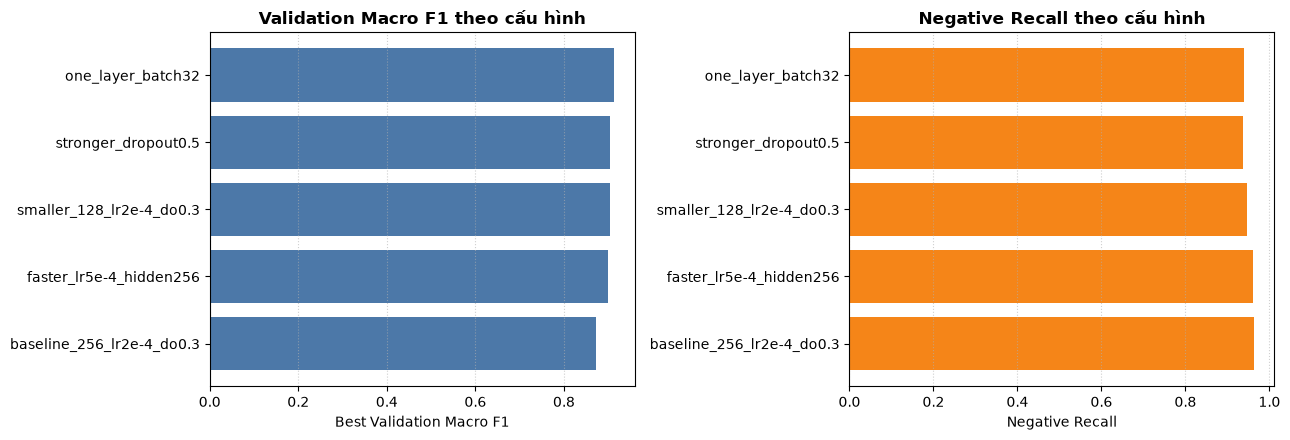

✅ Đã lưu hình tuning tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_hyperparameter_tuning.png


In [14]:
# Tuning nhanh: chỉ thử một số cấu hình đại diện để notebook vẫn chạy được trong thời gian hợp lý.
TUNING_EPOCHS = 3 #Số vòng epoch để train thử
TUNING_PATIENCE = 2

# Mỗi config thay đổi một vài yếu tố quan trọng để quan sát ảnh hưởng.
tuning_configs = [
    DEFAULT_LSTM_CONFIG,
    {**DEFAULT_LSTM_CONFIG, 'name': 'smaller_128_lr2e-4_do0.3', 'hidden_dim': 128},
    {**DEFAULT_LSTM_CONFIG, 'name': 'faster_lr5e-4_hidden256', 'learning_rate': 0.0005},
    {**DEFAULT_LSTM_CONFIG, 'name': 'stronger_dropout0.5', 'dropout': 0.5},
    {**DEFAULT_LSTM_CONFIG, 'name': 'one_layer_batch32', 'n_layers': 1, 'batch_size': 32},
]

tuning_results = []
tuning_histories = {}

for config in tuning_configs:
    # Duyệt lần lượt từng bộ hyperparameter trong danh sách tuning_configs.
    print(f"\n🔎 Đang tuning cấu hình: {config['name']}")

    # Tạo DataLoader riêng cho cấu hình hiện tại.
    # Lý do: một số config có batch_size khác nhau, nên cần build lại loader theo đúng batch_size đó.
    tune_train_loader, tune_val_loader, _ = build_loaders(batch_size=config['batch_size'])

    # Train nhanh mô hình với config hiện tại trên train set,
    # sau đó đánh giá trên validation set để lấy metric so sánh.
    tuned_model, tune_history_df, tune_summary = run_lstm_experiment(
        config=config,  # Bộ hyperparameter đang được thử nghiệm.
        train_loader=tune_train_loader,  # Dữ liệu dùng để cập nhật trọng số mô hình.
        val_loader=tune_val_loader,      # Dữ liệu dùng để đánh giá model sau mỗi epoch, không dùng để train.
        max_epochs=TUNING_EPOCHS,        # Số epoch nhỏ để tuning nhanh, chưa phải train final.
        patience=TUNING_PATIENCE,        # Early stopping: dừng sớm nếu validation loss không cải thiện.
        monitor='val_loss',              # Chọn best checkpoint dựa trên validation loss thấp nhất.
        verbose=False                    # Tắt log chi tiết từng epoch để output tuning gọn hơn.
    )

    val_probs_tune, y_val_tune = collect_predictions(tuned_model, tune_val_loader)
    val_class_metrics = classification_metrics_from_probs(y_val_tune, val_probs_tune, threshold=0.5)

    tuning_results.append({
        'config_name': config['name'],
        'learning_rate': config['learning_rate'],
        'hidden_dim': config['hidden_dim'],
        'dropout': config['dropout'],
        'n_layers': config['n_layers'],
        'batch_size': config['batch_size'],
        'best_epoch': tune_summary['best_epoch'],
        'best_val_loss': tune_summary['best_val_loss'],
        'best_val_macro_f1': tune_summary['best_val_f1'],
        'negative_recall': val_class_metrics['negative_recall'],
        'negative_f1': val_class_metrics['negative_f1'],
        'train_time_sec': tune_summary['train_time'],
    })
    tuning_histories[config['name']] = tune_history_df

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by=['best_val_macro_f1', 'negative_recall', 'best_val_loss'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(tuning_results_df.round(4))

best_config_name = tuning_results_df.loc[0, 'config_name']
best_lstm_config = copy.deepcopy(next(config for config in tuning_configs if config['name'] == best_config_name))
print(f"✅ Cấu hình được chọn để train final model: {best_config_name}")

# Vẽ kết quả tuning để đưa vào report/slide nếu cần.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_df = tuning_results_df.sort_values('best_val_macro_f1', ascending=True)

axes[0].barh(plot_df['config_name'], plot_df['best_val_macro_f1'], color='#4C78A8')
axes[0].set_title('Validation Macro F1 theo cấu hình', fontsize=12, weight='bold')
axes[0].set_xlabel('Best Validation Macro F1')
axes[0].grid(True, axis='x', linestyle=':', alpha=0.6)

axes[1].barh(plot_df['config_name'], plot_df['negative_recall'], color='#F58518')
axes[1].set_title('Negative Recall theo cấu hình', fontsize=12, weight='bold')
axes[1].set_xlabel('Negative Recall')
axes[1].grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
tuning_figure_path = FIGURES_DIR / 'lstm_hyperparameter_tuning.png'
fig.savefig(tuning_figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Đã lưu hình tuning tại: {tuning_figure_path}")

### Nhận xét: Best model được chọn tự động

Sau khi train nhanh từng cấu hình trên validation set, notebook chọn cấu hình tốt nhất theo thứ tự ưu tiên: `best_val_macro_f1` cao nhất, sau đó xét thêm `negative_recall`, cuối cùng mới xét `best_val_loss`. Cách chọn này giúp mô hình không chỉ tốt về hiệu suất tổng thể mà còn phù hợp với mục tiêu phát hiện review tiêu cực.

Cấu hình được chọn là **`one_layer_batch32`**, tức một mô hình **Bidirectional LSTM một tầng** với các hyperparameter chính:

| Hyperparameter | Giá trị |
| :--- | ---: |
| `embedding_dim` | 128 |
| `hidden_dim` | 256 |
| `n_layers` | 1 |
| `batch_size` | 32 |
| `learning_rate` | 0.0002 |
| `weight_decay` | 0.00001 |
| `dropout` | 0.3 |

Điểm đặc biệt là cấu hình này **đơn giản hơn mô hình LSTM ban đầu** nhưng lại cho kết quả validation tốt hơn trong nhóm cấu hình thử nghiệm. Với `n_layers = 1`, dropout trong `nn.LSTM` thực tế không được áp dụng bên trong LSTM, vì PyTorch chỉ dùng dropout giữa các tầng khi có từ hai tầng trở lên. Như vậy, điểm mạnh của cấu hình này đến từ việc giảm độ sâu mô hình và dùng `batch_size = 32`, giúp mô hình cập nhật trọng số thường xuyên hơn, học ổn định hơn trên bộ dữ liệu hiện tại.

Sau bước chọn hyperparameter, notebook tiếp tục train final model với `EPOCHS = 10` và chọn **best checkpoint tại epoch 8** dựa trên validation loss. Vì vậy, “best model” cuối cùng gồm hai phần: best architecture/config là `one_layer_batch32`, và best checkpoint là trọng số ở epoch 8.


### 2.3.5: Train model cuối cùng với EPOCHS = 10

In [15]:
# Train final model bằng cấu hình tốt nhất từ tuning.
# Đặt EPOCHS = 10 để learning curves đủ dài, nhìn được xu hướng hội tụ/overfit rõ hơn 3 epoch.
EPOCHS = 10
PATIENCE = 3

train_loader, val_loader, test_loader = build_loaders(batch_size=best_lstm_config['batch_size'])

model, history_df, final_train_summary = run_lstm_experiment(
    config=best_lstm_config,
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=EPOCHS,
    patience=PATIENCE,
    monitor='val_loss',
    verbose=True
)

# Chuyển DataFrame về dict để dùng lại với hàm vẽ history ở cell sau.
history = {col: history_df[col].tolist() for col in history_df.columns if col != 'epoch'}
train_time = final_train_summary['train_time']
best_epoch = final_train_summary['best_epoch']

display(history_df.round(4))
print(f"✅ Best epoch: {best_epoch}/{len(history_df)}")
print(f"✅ Best validation loss: {final_train_summary['best_val_loss']:.4f}")
print(f"✅ Best validation Macro F1: {final_train_summary['best_val_f1']:.4f}")

Epoch 01/10 | train_loss=0.4822 | val_loss=0.3343 | train_acc=75.85% | val_acc=85.93% | train_macro_f1=0.7301 | val_macro_f1=0.8488 | train_mae=0.3291 | val_mae=0.1965 | patience=0/3
Epoch 02/10 | train_loss=0.2893 | val_loss=0.2798 | train_acc=88.03% | val_acc=89.52% | train_macro_f1=0.8741 | val_macro_f1=0.8877 | train_mae=0.1770 | val_mae=0.1630 | patience=0/3
Epoch 03/10 | train_loss=0.2320 | val_loss=0.2770 | train_acc=91.06% | val_acc=89.59% | train_macro_f1=0.9060 | val_macro_f1=0.8913 | train_mae=0.1399 | val_mae=0.1694 | patience=0/3
Epoch 04/10 | train_loss=0.1920 | val_loss=0.2241 | train_acc=92.89% | val_acc=91.17% | train_macro_f1=0.9251 | val_macro_f1=0.9072 | train_mae=0.1120 | val_mae=0.1310 | patience=0/3
Epoch 05/10 | train_loss=0.1578 | val_loss=0.2240 | train_acc=94.26% | val_acc=91.72% | train_macro_f1=0.9398 | val_macro_f1=0.9123 | train_mae=0.0931 | val_mae=0.1146 | patience=0/3
Epoch 06/10 | train_loss=0.1335 | val_loss=0.2256 | train_acc=95.35% | val_acc=92.02%

,epoch,train_loss,val_loss,train_acc,val_acc,train_f1,val_f1,train_mae,val_mae
0,1,0.4822,0.3343,75.8549,85.9318,0.7301,0.8488,0.3291,0.1965
1,2,0.2893,0.2798,88.0318,89.5250,0.8741,0.8877,0.1770,0.1630
2,3,0.2320,0.2770,91.0598,89.5859,0.9060,0.8913,0.1399,0.1694
3,4,0.1920,0.2241,92.8870,91.1693,0.9251,0.9072,0.1120,0.1310
4,5,0.1578,0.2240,94.2574,91.7174,0.9398,0.9123,0.0931,0.1146
5,6,0.1335,0.2256,95.3537,92.0219,0.9513,0.9158,0.0760,0.1019
6,7,0.1146,0.2141,96.2542,92.8745,0.9607,0.9255,0.0652,0.0921
7,8,0.0943,0.2092,96.7502,93.3618,0.9660,0.9304,0.0540,0.0796
8,9,0.0814,0.2247,97.3245,93.4836,0.9720,0.9309,0.0455,0.0801
9,10,0.0723,0.2255,97.8987,93.7881,0.9780,0.9346,0.0390,0.0733


✅ Best epoch: 8/10
✅ Best validation loss: 0.2092
✅ Best validation Macro F1: 0.9304


### 2.3.6: Vẽ xu hướng học của model qua các epoch

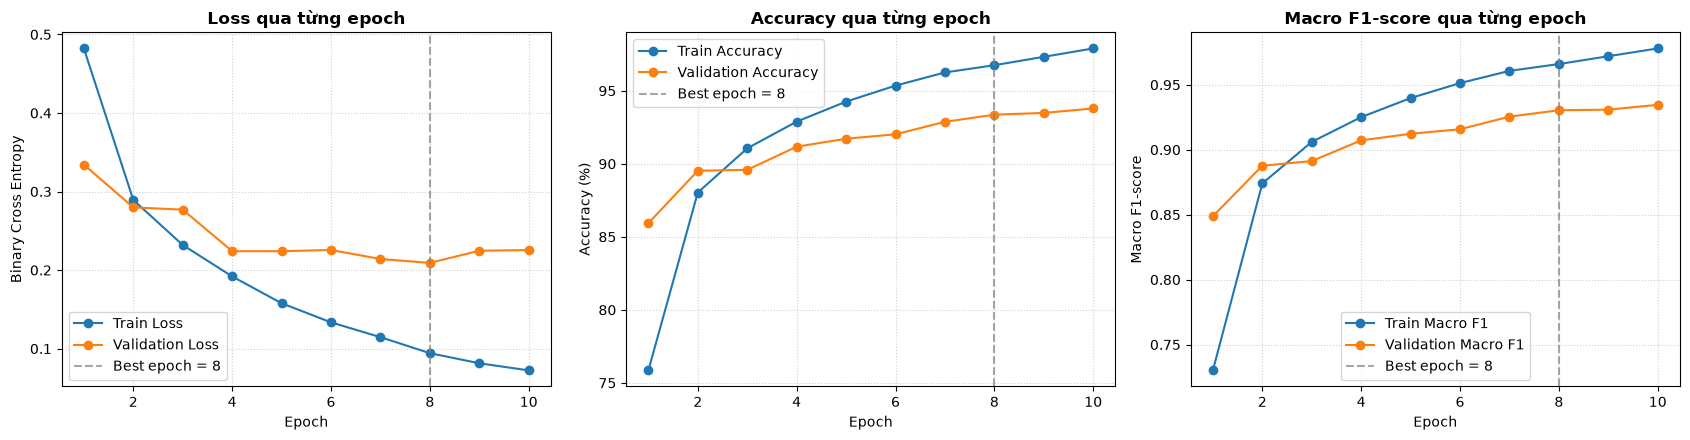

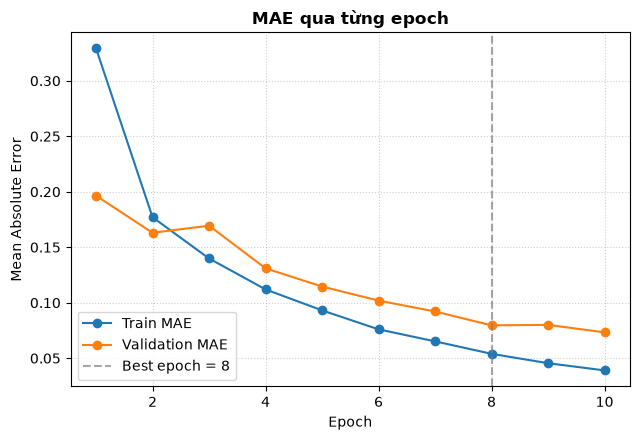

✅ Đã lưu learning curves tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_learning_curves.png
✅ Đã lưu MAE curve tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_mae_by_epoch.png


In [16]:
def plot_training_history(history_df, figures_dir=FIGURES_DIR):
    """Vẽ và lưu các biểu đồ thể hiện xu hướng học của LSTM qua từng epoch."""
    if history_df.empty:
        raise ValueError("history_df đang rỗng. Hãy chạy cell train model trước khi vẽ biểu đồ.")

    epochs = history_df['epoch'].values

    # Hình 1: Learning curves cho Loss, Accuracy và Macro F1-score.
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    axes[0].plot(epochs, history_df['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(epochs, history_df['val_loss'], marker='o', label='Validation Loss')
    axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch = {best_epoch}')
    axes[0].set_title('Loss qua từng epoch', fontsize=12, weight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross Entropy')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend()

    axes[1].plot(epochs, history_df['train_acc'], marker='o', label='Train Accuracy')
    axes[1].plot(epochs, history_df['val_acc'], marker='o', label='Validation Accuracy')
    axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch = {best_epoch}')
    axes[1].set_title('Accuracy qua từng epoch', fontsize=12, weight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend()

    axes[2].plot(epochs, history_df['train_f1'], marker='o', label='Train Macro F1')
    axes[2].plot(epochs, history_df['val_f1'], marker='o', label='Validation Macro F1')
    axes[2].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch = {best_epoch}')
    axes[2].set_title('Macro F1-score qua từng epoch', fontsize=12, weight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Macro F1-score')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    axes[2].legend()

    plt.tight_layout()
    learning_curve_path = figures_dir / 'lstm_learning_curves.png'
    fig.savefig(learning_curve_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Hình 2: MAE giúp quan sát độ lệch xác suất dự đoán so với nhãn thật.
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(epochs, history_df['train_mae'], marker='o', label='Train MAE')
    ax.plot(epochs, history_df['val_mae'], marker='o', label='Validation MAE')
    ax.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch = {best_epoch}')
    ax.set_title('MAE qua từng epoch', fontsize=12, weight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Absolute Error')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

    plt.tight_layout()
    mae_curve_path = figures_dir / 'lstm_mae_by_epoch.png'
    fig.savefig(mae_curve_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Đã lưu learning curves tại: {learning_curve_path}")
    print(f"✅ Đã lưu MAE curve tại: {mae_curve_path}")

    return learning_curve_path, mae_curve_path

learning_curve_path, mae_curve_path = plot_training_history(history_df)

### Nhận xét: Learning curves và MAE

Biểu đồ `Loss` cho biết mô hình còn đang học ổn định hay bắt đầu overfit. `Accuracy` và `Macro F1-score` giúp nhìn chất lượng phân loại theo epoch, trong đó Macro F1 hữu ích hơn accuracy khi cần quan tâm đồng thời cả hai lớp Positive/Negative. `MAE` không phải metric chính của classification, nhưng giúp quan sát xác suất dự đoán có tiến gần nhãn thật hơn qua quá trình huấn luyện hay không.

# 3. Đánh giá model

## 3.0: Helper đánh giá và visualization

In [17]:
THRESHOLD = 0.5
TARGET_NAMES = ['Negative', 'Positive']


def evaluation_table(y_true, y_prob, threshold: float = 0.5):
    """Tạo bảng classification report dạng DataFrame để dễ đọc trong notebook."""
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    report = classification_report(
        y_true,
        y_pred,
        target_names=TARGET_NAMES,
        digits=4,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).transpose()

    # Riêng accuracy trong classification_report là một số scalar, không phải dict như các dòng class.
    # Nếu chuyển thẳng sang DataFrame, pandas sẽ lặp accuracy sang cả cột support và dễ gây hiểu nhầm.
    if 'accuracy' in report_df.index:
        report_df.loc['accuracy', ['precision', 'recall']] = np.nan
        report_df.loc['accuracy', 'f1-score'] = report['accuracy']
        report_df.loc['accuracy', 'support'] = len(y_true)

    return report_df


def plot_confusion_matrix_and_roc(y_true, y_prob, threshold: float, figure_path, title_suffix=''):
    """Vẽ confusion matrix và ROC curve cho một threshold cố định."""
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=[f'Pred {n}' for n in TARGET_NAMES],
                yticklabels=[f'Actual {n}' for n in TARGET_NAMES],
                annot_kws={'size': 12, 'weight': 'bold'})
    axes[0].set_title(f'Ma trận nhầm lẫn {title_suffix}', fontsize=12, weight='bold', pad=10)
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('Actual Label')

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (FPR)')
    axes[1].set_ylabel('True Positive Rate (TPR)')
    axes[1].set_title(f'ROC Curve {title_suffix}', fontsize=12, weight='bold', pad=10)
    axes[1].legend(loc='lower right')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    plt.show()

    return cm, roc_auc

### 3.1: Đánh giá mặc định với threshold = 0.5

===== Validation report - threshold 0.5 =====


,precision,recall,f1-score,support
Negative,0.9439,0.9468,0.9454,996.0
Positive,0.9176,0.9133,0.9154,646.0
accuracy,NaN,NaN,0.9336,1642.0
macro avg,0.9308,0.9300,0.9304,1642.0
weighted avg,0.9336,0.9336,0.9336,1642.0


===== Test report - threshold 0.5 =====


,precision,recall,f1-score,support
Negative,0.9489,0.9318,0.9403,997.0
Positive,0.8976,0.9226,0.9099,646.0
accuracy,NaN,NaN,0.9282,1643.0
macro avg,0.9233,0.9272,0.9251,1643.0
weighted avg,0.9287,0.9282,0.9283,1643.0


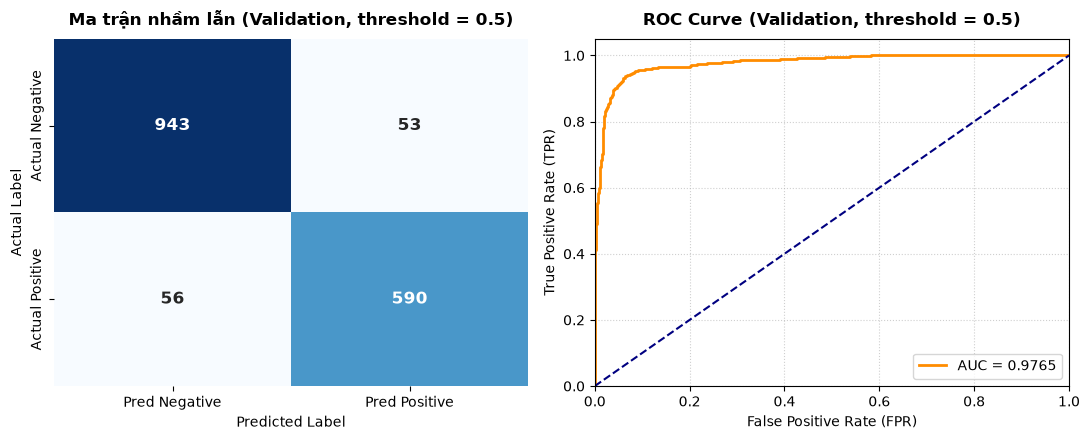

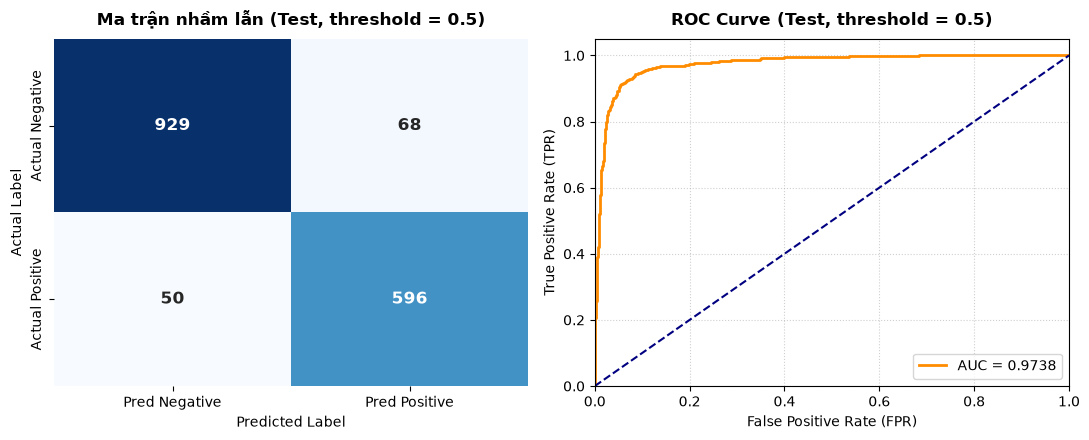

✅ Đã lưu hình Validation threshold 0.5 tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_validation_default_eval.png
✅ Đã lưu hình Test threshold 0.5 tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_test_default_eval.png
✅ Đã cập nhật hình report cũ tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/danhgia_1_LSTM.png


In [18]:
# Lấy xác suất từ validation và test sau khi final model đã được load best checkpoint.
val_probs, y_val_true = collect_predictions(model, val_loader)
test_probs, y_test_true = collect_predictions(model, test_loader)

print("===== Validation report - threshold 0.5 =====")
val_default_report_df = evaluation_table(y_val_true, val_probs, threshold=0.5)
display(val_default_report_df.round(4))

print("===== Test report - threshold 0.5 =====")
test_default_report_df = evaluation_table(y_test_true, test_probs, threshold=0.5)
display(test_default_report_df.round(4))

default_val_metrics = classification_metrics_from_probs(y_val_true, val_probs, threshold=0.5)
default_test_metrics = classification_metrics_from_probs(y_test_true, test_probs, threshold=0.5)

# Vẽ riêng Validation và Test để tiêu đề rõ ràng, tránh nhầm đây là hai biểu đồ giống nhau.
validation_default_eval_path = FIGURES_DIR / 'lstm_validation_default_eval.png'
cm_val_default, roc_auc_val_default = plot_confusion_matrix_and_roc(
    y_val_true,
    val_probs,
    threshold=0.5,
    figure_path=validation_default_eval_path,
    title_suffix='(Validation, threshold = 0.5)'
)

default_eval_path = FIGURES_DIR / 'lstm_test_default_eval.png'
cm_default, roc_auc_default = plot_confusion_matrix_and_roc(
    y_test_true,
    test_probs,
    threshold=0.5,
    figure_path=default_eval_path,
    title_suffix='(Test, threshold = 0.5)'
)

# Cập nhật tên ảnh cũ cho final_report mà không vẽ thêm lần thứ hai trong notebook.
legacy_default_path = FIGURES_DIR / 'danhgia_1_LSTM.png'
shutil.copyfile(default_eval_path, legacy_default_path)

print(f"✅ Đã lưu hình Validation threshold 0.5 tại: {validation_default_eval_path}")
print(f"✅ Đã lưu hình Test threshold 0.5 tại: {default_eval_path}")
print(f"✅ Đã cập nhật hình report cũ tại: {legacy_default_path}")

### Nhận xét: Threshold mặc định

Threshold `0.5` là điểm xuất phát cân bằng: xác suất Positive từ 0.5 trở lên thì dự đoán Positive, thấp hơn thì dự đoán Negative. Kết quả này dùng để so sánh với threshold đã tuning ở phần sau, đặc biệt khi mục tiêu nghiệp vụ là giảm bỏ sót review tiêu cực.

### 3.2: Threshold tuning để tăng Negative Recall

Chọn trong các threshold đạt Negative Recall >= 96%.
✅ Threshold được chọn trên validation set: 0.66


,threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,negative_support,positive_precision,positive_recall,positive_f1,positive_support
22,0.32,0.9367,0.9340,0.9579,0.9367,0.9472,996,0.9057,0.9365,0.9209,646
23,0.33,0.9367,0.9340,0.9579,0.9367,0.9472,996,0.9057,0.9365,0.9209,646
21,0.31,0.9367,0.9340,0.9579,0.9367,0.9472,996,0.9057,0.9365,0.9209,646
56,0.66,0.9348,0.9312,0.9337,0.9608,0.9471,996,0.9368,0.8947,0.9153,646
44,0.54,0.9354,0.9322,0.9423,0.9518,0.9471,996,0.9245,0.9102,0.9173,646
45,0.55,0.9354,0.9322,0.9423,0.9518,0.9471,996,0.9245,0.9102,0.9173,646
55,0.65,0.9348,0.9312,0.9345,0.9598,0.9470,996,0.9354,0.8963,0.9154,646
54,0.64,0.9348,0.9312,0.9354,0.9588,0.9470,996,0.9340,0.8978,0.9155,646
26,0.36,0.9361,0.9333,0.9541,0.9398,0.9469,996,0.9092,0.9303,0.9197,646
51,0.61,0.9348,0.9313,0.9371,0.9568,0.9468,996,0.9312,0.9009,0.9158,646


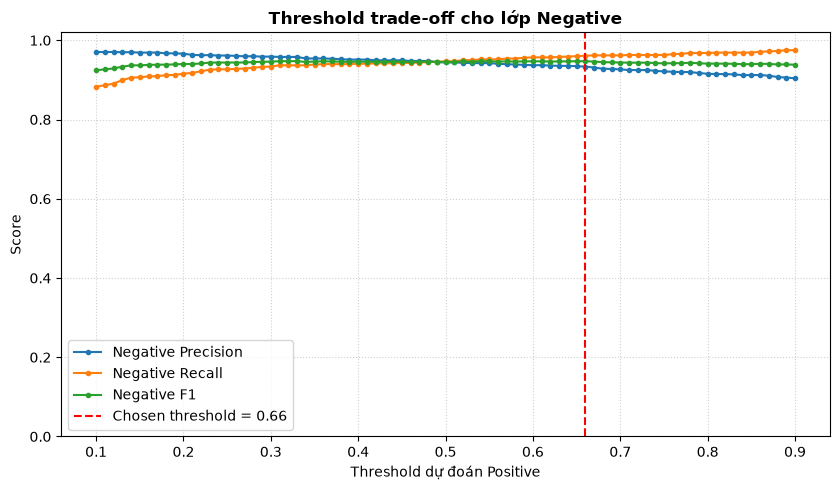

✅ Đã lưu hình threshold trade-off tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_threshold_tradeoff.png


In [19]:
def build_threshold_tradeoff(y_true, y_prob, thresholds=None):
    """Quét nhiều threshold và ghi lại trade-off giữa precision/recall/F1 của từng class."""
    if thresholds is None:
        thresholds = np.round(np.arange(0.10, 0.91, 0.01), 2)

    rows = []
    for threshold in thresholds:
        metrics = classification_metrics_from_probs(y_true, y_prob, threshold=float(threshold))
        rows.append(metrics)

    return pd.DataFrame(rows)


def choose_threshold_for_negative_recall(tradeoff_df, target_recall=0.96):
    """Chọn threshold đạt target Negative Recall, sau đó ưu tiên Negative F1 cao nhất."""
    candidates = tradeoff_df[tradeoff_df['negative_recall'] >= target_recall].copy()
    if candidates.empty:
        # Nếu target quá cao không đạt được, chọn threshold có Negative F1 tốt nhất để tránh cực đoan.
        candidates = tradeoff_df.copy()
        reason = 'Không có threshold đạt target recall, chọn theo Negative F1 cao nhất.'
    else:
        reason = f'Chọn trong các threshold đạt Negative Recall >= {target_recall:.0%}.'

    best_row = candidates.sort_values(
        by=['negative_f1', 'negative_precision', 'accuracy'],
        ascending=[False, False, False]
    ).iloc[0]
    return best_row, reason


def plot_threshold_tradeoff(tradeoff_df, best_threshold, figure_path):
    """Vẽ ảnh hưởng của threshold lên precision/recall/F1 của lớp Negative."""
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(tradeoff_df['threshold'], tradeoff_df['negative_precision'], label='Negative Precision', marker='o', markersize=3)
    ax.plot(tradeoff_df['threshold'], tradeoff_df['negative_recall'], label='Negative Recall', marker='o', markersize=3)
    ax.plot(tradeoff_df['threshold'], tradeoff_df['negative_f1'], label='Negative F1', marker='o', markersize=3)
    ax.axvline(best_threshold, color='red', linestyle='--', label=f'Chosen threshold = {best_threshold:.2f}')
    ax.set_title('Threshold trade-off cho lớp Negative', fontsize=12, weight='bold')
    ax.set_xlabel('Threshold dự đoán Positive')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.02)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    plt.show()

# Chọn threshold trên validation set, tuyệt đối không chọn bằng test set.
threshold_tradeoff_df = build_threshold_tradeoff(y_val_true, val_probs)
best_threshold_row, threshold_reason = choose_threshold_for_negative_recall(
    threshold_tradeoff_df,
    target_recall=0.96
)
BEST_THRESHOLD = float(best_threshold_row['threshold'])

print(threshold_reason)
print(f"✅ Threshold được chọn trên validation set: {BEST_THRESHOLD:.2f}")
display(threshold_tradeoff_df.sort_values('negative_f1', ascending=False).head(10).round(4))

threshold_figure_path = FIGURES_DIR / 'lstm_threshold_tradeoff.png'
plot_threshold_tradeoff(threshold_tradeoff_df, BEST_THRESHOLD, threshold_figure_path)
print(f"✅ Đã lưu hình threshold trade-off tại: {threshold_figure_path}")

### Nhận xét: Logic threshold cho lớp Negative

Model trả về xác suất của lớp `Positive`, nên khi **tăng threshold**, mô hình sẽ khó dự đoán một câu là Positive hơn và nhiều câu hơn sẽ được chuyển sang Negative. Trade-off là Negative Recall tăng nhưng Negative Precision có thể giảm vì một số câu Positive bị kéo nhầm sang Negative.

### 3.3: Precision-Recall curve cho lớp Negative

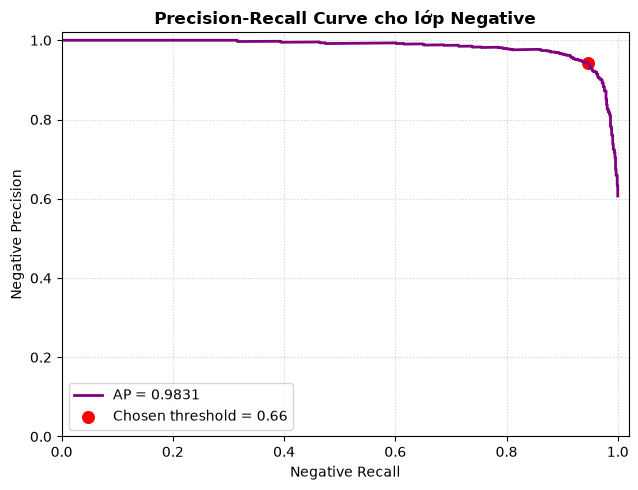

✅ Negative Average Precision trên test set: 0.9831
✅ Đã lưu PR curve tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_negative_pr_curve.png


In [20]:
def plot_negative_pr_curve(y_true, y_prob, chosen_threshold, figure_path):
    """Vẽ Precision-Recall curve cho lớp Negative bằng score Negative = 1 - P(Positive)."""
    y_true_negative = (np.asarray(y_true) == 0).astype(int)
    negative_scores = 1 - np.asarray(y_prob)

    precision, recall, score_thresholds = precision_recall_curve(y_true_negative, negative_scores)
    average_precision = average_precision_score(y_true_negative, negative_scores)

    # Threshold Positive tương ứng với Negative score threshold là 1 - threshold.
    chosen_negative_score = 1 - chosen_threshold
    nearest_idx = np.argmin(np.abs(score_thresholds - chosen_negative_score)) if len(score_thresholds) else 0

    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot(recall, precision, color='purple', lw=2, label=f'AP = {average_precision:.4f}')
    if len(score_thresholds):
        ax.scatter(recall[nearest_idx], precision[nearest_idx], color='red', s=70,
                   label=f'Chosen threshold = {chosen_threshold:.2f}')
    ax.set_title('Precision-Recall Curve cho lớp Negative', fontsize=12, weight='bold')
    ax.set_xlabel('Negative Recall')
    ax.set_ylabel('Negative Precision')
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    plt.show()

    return average_precision

negative_pr_path = FIGURES_DIR / 'lstm_negative_pr_curve.png'
negative_average_precision = plot_negative_pr_curve(
    y_test_true,
    test_probs,
    chosen_threshold=BEST_THRESHOLD,
    figure_path=negative_pr_path
)
print(f"✅ Negative Average Precision trên test set: {negative_average_precision:.4f}")
print(f"✅ Đã lưu PR curve tại: {negative_pr_path}")

### Nhận xét: Đường Precision-Recall của lớp Negative

Đường Precision-Recall cho lớp `Negative` nằm sát vùng trên của biểu đồ, cho thấy mô hình vẫn giữ được độ chính xác cao ngay cả khi tăng khả năng bao phủ các đánh giá tiêu cực. Chỉ số Average Precision cao cho thấy mô hình xếp hạng các mẫu tiêu cực khá tốt, tức là phần lớn review tiêu cực thật sự được gán điểm Negative cao hơn so với các review còn lại. Đây là một tín hiệu tích cực đối với bài toán chăm sóc khách hàng, vì nhóm có thể ưu tiên phát hiện sớm những phản hồi xấu mà không làm tăng quá nhiều cảnh báo sai.

### 3.4: Đánh giá cuối cùng trên test set

===== Test report - tuned threshold 0.66 =====


,precision,recall,f1-score,support
Negative,0.9430,0.9458,0.9444,997.0
Positive,0.9160,0.9118,0.9139,646.0
accuracy,NaN,NaN,0.9324,1643.0
macro avg,0.9295,0.9288,0.9292,1643.0
weighted avg,0.9324,0.9324,0.9324,1643.0


,setting,threshold,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,positive_precision,positive_recall,positive_f1
0,default_threshold_0.50,0.50,0.9282,0.9251,0.9489,0.9318,0.9403,0.8976,0.9226,0.9099
1,tuned_threshold_0.66,0.66,0.9324,0.9292,0.9430,0.9458,0.9444,0.9160,0.9118,0.9139


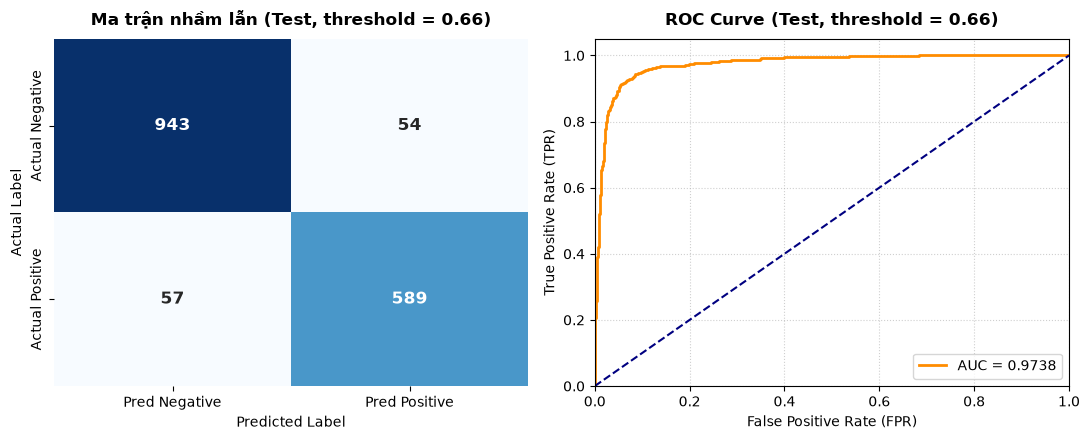

✅ Đã lưu hình đánh giá Test threshold tuned tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/lstm_test_tuned_eval.png
✅ Đã cập nhật hình report cũ tại: /Users/sanghoang211231/Documents/24KDL1/INTRO2DS/PROJECT/Customer-Sentiment-Analysis/reports/figures/danhgia_2_LSTM.png


In [21]:
print(f"===== Test report - tuned threshold {BEST_THRESHOLD:.2f} =====")
tuned_test_report_df = evaluation_table(y_test_true, test_probs, threshold=BEST_THRESHOLD)
display(tuned_test_report_df.round(4))

tuned_test_metrics = classification_metrics_from_probs(y_test_true, test_probs, threshold=BEST_THRESHOLD)

compare_threshold_df = pd.DataFrame([
    {'setting': 'default_threshold_0.50', **default_test_metrics},
    {'setting': f'tuned_threshold_{BEST_THRESHOLD:.2f}', **tuned_test_metrics},
])

display(compare_threshold_df[[
    'setting', 'threshold', 'accuracy', 'macro_f1',
    'negative_precision', 'negative_recall', 'negative_f1',
    'positive_precision', 'positive_recall', 'positive_f1'
]].round(4))

tuned_eval_path = FIGURES_DIR / 'lstm_test_tuned_eval.png'
cm_tuned, roc_auc_tuned = plot_confusion_matrix_and_roc(
    y_test_true,
    test_probs,
    threshold=BEST_THRESHOLD,
    figure_path=tuned_eval_path,
    title_suffix=f'(Test, threshold = {BEST_THRESHOLD:.2f})'
)

# Cập nhật tên ảnh cũ cho final_report mà không vẽ thêm lần thứ hai trong notebook.
legacy_tuned_path = FIGURES_DIR / 'danhgia_2_LSTM.png'
shutil.copyfile(tuned_eval_path, legacy_tuned_path)

print(f"✅ Đã lưu hình đánh giá Test threshold tuned tại: {tuned_eval_path}")
print(f"✅ Đã cập nhật hình report cũ tại: {legacy_tuned_path}")

### Nhận xét: So sánh threshold 0.5 và threshold tuned

Threshold mặc định thường cho kết quả cân bằng tổng thể hơn. Threshold tuned được chọn trên validation set để ưu tiên Negative Recall, tức là giảm số review tiêu cực bị bỏ sót. Nếu Negative Recall tăng nhưng Precision giảm nhẹ, đây là đánh đổi có thể chấp nhận được trong bối cảnh doanh nghiệp muốn phát hiện sớm phản hồi xấu để xử lý.

### 3.5: Demo inference với một số câu thủ công

In [22]:
try:
    from underthesea import word_tokenize
except ImportError:
    word_tokenize = None


class SentimentPredictor:
    """Đóng gói logic dự đoán nhanh cho mô hình Sentiment LSTM."""
    def __init__(self, model, tokenizer, max_length=128, use_word_segmentation=True):
        self.model = model
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.use_word_segmentation = use_word_segmentation
        self.device = next(model.parameters()).device
        self.model.eval()

    def preprocess_text(self, text):
        """Tách từ tiếng Việt trước khi tokenization để inference gần hơn với dữ liệu train."""
        text = str(text)
        if self.use_word_segmentation and word_tokenize is not None:
            return word_tokenize(text, format='text')
        return text

    def predict(self, texts, threshold=BEST_THRESHOLD):
        """Dự đoán một câu hoặc một list câu, trả về nhãn và xác suất Positive."""
        texts = [texts] if isinstance(texts, str) else texts
        raw_probs, processed_texts = [], []

        with torch.inference_mode():
            for text in texts:
                # Tokenizer PhoBERT hoạt động tốt hơn khi câu tiếng Việt đã được tách từ bằng dấu gạch dưới.
                processed_text = self.preprocess_text(text)
                processed_texts.append(processed_text)
                tokens = self.tokenizer(
                    processed_text,
                    max_length=self.max_length,
                    padding='max_length',
                    truncation=True,
                    return_tensors='pt'
                )
                input_ids = tokens['input_ids'].long().to(self.device)
                y_prob = self.model(input_ids).squeeze(1).item()
                raw_probs.append(y_prob)

        probs = np.asarray(raw_probs)
        preds = (probs >= threshold).astype(int)
        return preds, probs, processed_texts

    def predict_and_print(self, text_input, threshold=BEST_THRESHOLD):
        """In kết quả dự đoán theo format dễ đọc cho phần demo."""
        labels, probs, processed_texts = self.predict(text_input, threshold=threshold)
        label, prob = labels[0], probs[0]
        sentiment = 'POSITIVE (Tích cực)' if label == 1 else 'NEGATIVE (Tiêu cực)'
        print(f"📝 Văn bản gốc: {text_input}")
        print(f"🔤 Sau tách từ: {processed_texts[0]}")
        print(f"📊 Xác suất Positive: {prob * 100:.2f}% | Threshold: {threshold:.2f}")
        print(f"🎯 Kết luận: {sentiment}")
        print('-' * 70)

# Tokenizer VinAI đã được dùng ở preprocessing nên dùng lại để inference đồng bộ.
TOKENIZER_NAME = 'vinai/phobert-base'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
engine = SentimentPredictor(model, tokenizer, use_word_segmentation=True)

demo_examples = [
    'Sản phẩm rất đẹp, giao hàng nhanh, đóng gói cẩn thận.',
    'Áo xấu, chất vải mỏng, mặc một lần đã bung chỉ.',
    'Hàng cũng ổn nhưng giao hơi lâu, shop trả lời chậm.',
    'Tốt, không tốt, đẹp, xấu, hay, dở, vui, buồn.',
    'Sản phẩm đẹp nhưng chủ shop nói chuyện hơi cọc, mong cải thiện.',
]

for text in demo_examples:
    engine.predict_and_print(text)

📝 Văn bản gốc: Sản phẩm rất đẹp, giao hàng nhanh, đóng gói cẩn thận.
🔤 Sau tách từ: Sản_phẩm rất đẹp , giao hàng nhanh , đóng_gói cẩn_thận .
📊 Xác suất Positive: 99.81% | Threshold: 0.66
🎯 Kết luận: POSITIVE (Tích cực)
----------------------------------------------------------------------
📝 Văn bản gốc: Áo xấu, chất vải mỏng, mặc một lần đã bung chỉ.
🔤 Sau tách từ: Áo xấu , chất vải mỏng , mặc một lần đã bung chỉ .
📊 Xác suất Positive: 3.66% | Threshold: 0.66
🎯 Kết luận: NEGATIVE (Tiêu cực)
----------------------------------------------------------------------
📝 Văn bản gốc: Hàng cũng ổn nhưng giao hơi lâu, shop trả lời chậm.
🔤 Sau tách từ: Hàng cũng ổn nhưng giao hơi lâu , shop trả_lời chậm .
📊 Xác suất Positive: 0.78% | Threshold: 0.66
🎯 Kết luận: NEGATIVE (Tiêu cực)
----------------------------------------------------------------------
📝 Văn bản gốc: Tốt, không tốt, đẹp, xấu, hay, dở, vui, buồn.
🔤 Sau tách từ: Tốt , không tốt , đẹp , xấu , hay , dở , vui , buồn .
📊 Xác suất Positive

### Nhận xét: Các câu khó khi inference

Các câu có cả khen và chê thường khó hơn câu cảm xúc rõ ràng vì mô hình phải tự xác định phần nào mang trọng số cảm xúc mạnh hơn. Khi nhập câu thủ công, cần đưa text qua bước tách từ giống pipeline train; nếu bỏ qua preprocessing, xác suất dự đoán có thể lệch mạnh vì phân phối input khác dữ liệu huấn luyện. Những câu nhập nhằng, mỉa mai hoặc liệt kê nhiều từ trái nghĩa vẫn là nhóm dễ sai, nhất là khi mô hình chỉ dựa vào text và chưa dùng thêm metadata như rating.